В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import os

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from ml_homework.classification import (
    compute_auroc_and_build_roc,
    get_f1_score,
    predict_and_plot,
    predict_majority_class,
    predict_raw_df,
)
from ml_homework.paths import PROCESSED_DATA_DIR, RAW_DATA_DIR

In [2]:
raw_df = pd.read_csv(RAW_DATA_DIR / "customer_churn/train.csv")

In [3]:
raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [4]:
X = raw_df.drop(columns="Exited")
y = raw_df["Exited"]

In [5]:
train_df, val_df = train_test_split(raw_df, test_size=0.25, random_state=42, stratify=y)

In [6]:
print("train_df.shape :", train_df.shape)
print("val_df.shape :", val_df.shape)

train_df.shape : (11250, 14)
val_df.shape : (3750, 14)


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [7]:
input_cols = X.columns.to_list()
target_col = y.name

In [8]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [9]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [10]:
identifier_cols = ["id", "CustomerId"]
discrete_cols = [
    "Tenure",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
]

numeric_cols = (
    train_inputs.select_dtypes(include=np.number)
    .columns.difference([*identifier_cols, *discrete_cols])
    .tolist()
)
categorical_cols = (
    train_inputs.select_dtypes(include=["str", "object"])
    .columns.difference(["Surname"])
    .tolist()
    + discrete_cols
)

In [11]:
numeric_cols, categorical_cols

(['Age', 'Balance', 'CreditScore', 'EstimatedSalary'],
 ['Gender',
  'Geography',
  'Tenure',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [12]:
train_inputs[numeric_cols].describe().round(2)

,Age,Balance,CreditScore,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00
mean,37.69,42952.89,658.99,117904.96
std,8.14,59923.39,72.12,45553.03
min,18.00,0.00,431.00,11.58
25%,32.00,0.00,603.00,83155.87
50%,37.00,0.00,661.00,123587.94
75%,42.00,109863.19,709.00,156774.94
max,72.00,209767.31,850.00,199992.48


In [13]:
train_inputs[categorical_cols].nunique()

Gender             2
Geography          3
Tenure            11
NumOfProducts      4
HasCrCard          2
IsActiveMember     2
dtype: int64

In [14]:
train_inputs["Geography"].unique()

<ArrowStringArray>
['France', 'Germany', 'Spain']
Length: 3, dtype: str

In [15]:
train_inputs["Gender"].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [16]:
train_inputs["Gender"].value_counts()

Gender
Male      6449
Female    4801
Name: count, dtype: int64

In [17]:
train_inputs[numeric_cols].isna().sum()

Age                0
Balance            0
CreditScore        0
EstimatedSalary    0
dtype: int64

In [18]:
train_inputs[categorical_cols].isna().sum()

Gender            0
Geography         0
Tenure            0
NumOfProducts     0
HasCrCard         0
IsActiveMember    0
dtype: int64

In [19]:
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

In [20]:
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))]
)

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

In [22]:
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [23]:
train_inputs = preprocessor.fit_transform(train_inputs)
val_inputs = preprocessor.transform(val_inputs)

In [24]:
display(train_inputs.head())
display(val_inputs.head())

,num__Age,num__Balance,num__CreditScore,num__EstimatedSalary,cat__Gender_Female,cat__Gender_Male,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Tenure_0.0,...,cat__Tenure_9.0,cat__Tenure_10.0,cat__NumOfProducts_1.0,cat__NumOfProducts_2.0,cat__NumOfProducts_3.0,cat__NumOfProducts_4.0,cat__HasCrCard_0.0,cat__HasCrCard_1.0,cat__IsActiveMember_0.0,cat__IsActiveMember_1.0
8263,-0.698563,1.463179,0.513193,-0.683158,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
14199,-0.698563,1.282909,-0.374256,1.313519,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1856,-1.926640,-0.716829,0.277465,0.981199,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3013,1.266360,-0.716829,0.637991,0.041916,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
8266,-0.330140,-0.716829,0.513193,-0.383769,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


,num__Age,num__Balance,num__CreditScore,num__EstimatedSalary,cat__Gender_Female,cat__Gender_Male,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Tenure_0.0,...,cat__Tenure_9.0,cat__Tenure_10.0,cat__NumOfProducts_1.0,cat__NumOfProducts_2.0,cat__NumOfProducts_3.0,cat__NumOfProducts_4.0,cat__HasCrCard_0.0,cat__HasCrCard_1.0,cat__IsActiveMember_0.0,cat__IsActiveMember_1.0
1855,-1.066986,1.280624,-1.608364,-1.363073,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1273,0.406706,1.350297,-0.845713,1.294460,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5414,-0.821371,-0.716829,-0.526786,0.709918,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
10923,2.248822,-0.716829,-0.859579,-0.328604,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
5835,0.529514,-0.716829,1.248112,1.402602,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


**Числові ознаки**. Перевірила числові колонки і помітила, що вони не мають пропущених значень, тому імпутацію не застосовувала. Оскільки числові ознаки мають суттєво різні масштаби, то вирішила застосувати StandardScaler, щоб привести їх до порівнюваного масштабу.

**Категоріальні та дискретні ознаки.** У `Gender` та `Geography` пропущених значень немає, тому імпутація також не потрібна. Для перетворення категорій у числовий формат використовую `OneHotEncoder`. `Tenure`, `NumOfProducts`, `HasCrCard` та `IsActiveMember` також кодую як дискретні категорії: відстань між їхніми числовими значеннями не обов’язково відповідає лінійній зміні ризику відтоку. Так Logistic Regression може оцінити окремий вплив кожного значення.

`id` та `CustomerId` не використовую як вхідні ознаки, оскільки вони є ідентифікаторами. `Surname` також виключаю з базової моделі через високу кардинальність і відсутність очевидного стабільного способу кодування.

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [25]:
train_inputs.to_parquet(PROCESSED_DATA_DIR / "train_inputs.parquet")
val_inputs.to_parquet(PROCESSED_DATA_DIR / "val_inputs.parquet")

train_targets.to_frame().to_parquet(PROCESSED_DATA_DIR / "train_targets.parquet")
val_targets.to_frame().to_parquet(PROCESSED_DATA_DIR / "val_targets.parquet")

In [26]:
os.listdir(PROCESSED_DATA_DIR)

['credit',
 'submission_log_reg.csv',
 'train_targets.parquet',
 'log_reg.joblib',
 'train_inputs.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [27]:
X_train = train_inputs.copy()
X_val = val_inputs.copy()

In [28]:
model = LogisticRegression(solver="liblinear", random_state=42)

model.fit(X_train, train_targets)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setti

In [29]:
val_preds = model.predict(X_val)
val_preds

array([0., 1., 0., ..., 0., 0., 0.], shape=(3750,))

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

Accuracy: 89.32%


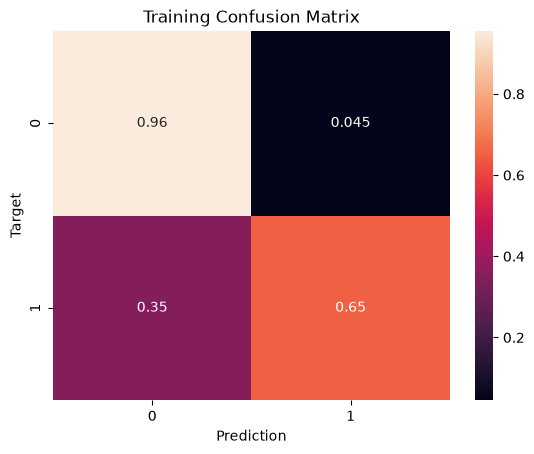

In [30]:
train_preds = predict_and_plot(model, X_train, train_targets, "Training")

Accuracy: 89.15%


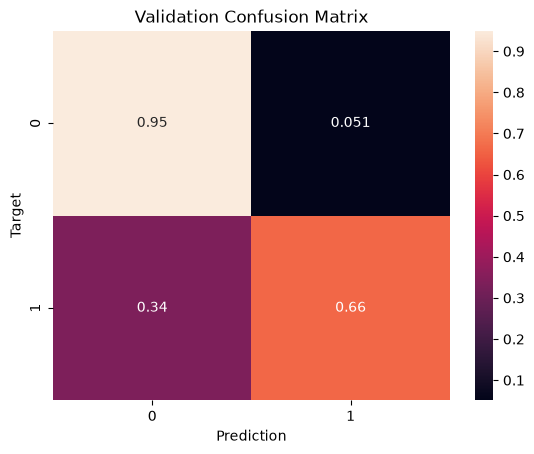

In [31]:
val_preds = predict_and_plot(model, X_val, val_targets, "Validation")

In [32]:
train_targets.value_counts(normalize=True)

Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64

In [33]:
get_f1_score(model, X_train, train_targets, "Training")
get_f1_score(model, X_val, val_targets, "Validation")

F1 score Training: 71.25%
F1 score Validation: 71.36%


0.7135819845179451

AUROC for Training: 0.93
AUROC for Validation: 0.92


0.9240500886102777

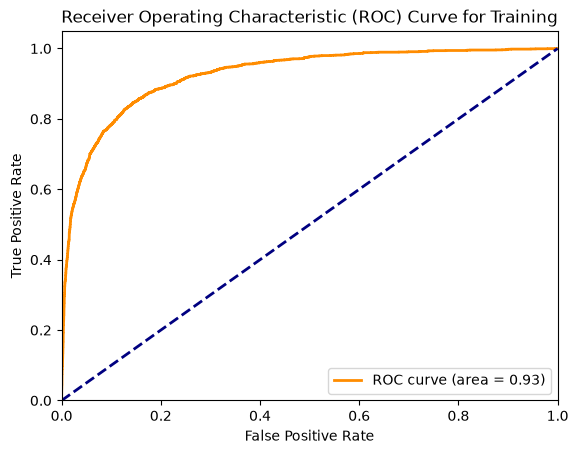

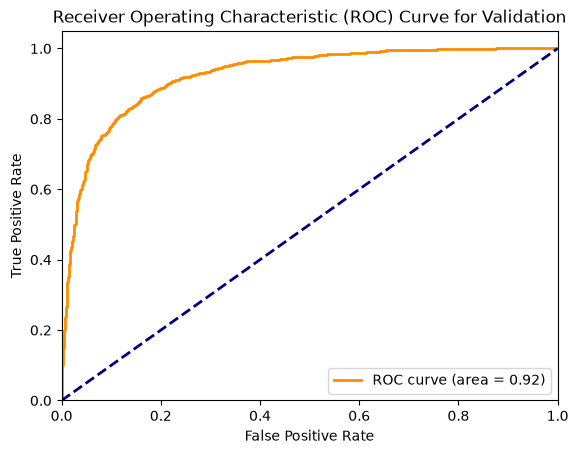

In [34]:
compute_auroc_and_build_roc(model, X_train, train_targets, "Training")
compute_auroc_and_build_roc(model, X_val, val_targets, "Validation")

Модель показала майже однакові результати на train і validation: Accuracy ≈ 89%, F1 ≈ 0.71, AUROC ≈ 0.92. Це означає, що явного перенавчання немає.

Оскільки клас `Exited=1` становить лише близько 20%, важливіше дивитися не тільки на Accuracy, а й на F1 та AUROC. За Confusion Matrix модель знаходить приблизно 66% клієнтів, які справді пішли. Кодування дискретних ознак окремими категоріями суттєво покращило результат Logistic Regression.


8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [35]:
majority_class = train_targets.mode()[0]

In [36]:
accuracy_score(
    train_targets,
    predict_majority_class(X_train, int(majority_class)),
)

0.7965333333333333

In [37]:
accuracy_score(
    val_targets,
    predict_majority_class(X_val, int(majority_class)),
)

0.7965333333333333

Базова модель, яка завжди прогнозує мажоритарний клас 0, має Accuracy близько 79.7%. Logistic Regression показує близько 89.2%, тому вона помітно краща за простий baseline і справді знаходить закономірності в даних.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [38]:
model_path = PROCESSED_DATA_DIR / "log_reg.joblib"
artifacts = {
    "preprocessor": preprocessor,
    "model": model,
}
joblib.dump(artifacts, model_path)

['/Users/olharyzha/Desktop/courses/ml/lessons/my_ml_home_work/data/processed/log_reg.joblib']

In [39]:
loaded_artifacts = joblib.load(model_path)
preprocessor_2 = loaded_artifacts["preprocessor"]
model_2 = loaded_artifacts["model"]

sample_inputs = raw_df[input_cols].head()
np.testing.assert_allclose(
    predict_raw_df(preprocessor, model, sample_inputs),
    predict_raw_df(preprocessor_2, model_2, sample_inputs),
)
model_2

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setti

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [40]:
predict_raw_df(preprocessor, model, raw_df[input_cols].head())

array([0.75148762, 0.01210017, 0.99631882, 0.17467871, 0.98709879])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [41]:
test_raw_df = pd.read_csv(RAW_DATA_DIR / "customer_churn/test.csv")

In [42]:
full_inputs = raw_df[input_cols].copy()
full_targets = raw_df[target_col].copy()

final_preprocessor = clone(preprocessor)
final_train_inputs = final_preprocessor.fit_transform(full_inputs)

final_model = clone(model)
final_model.fit(final_train_inputs, full_targets)

test_raw_df["Exited"] = predict_raw_df(
    final_preprocessor,
    final_model,
    test_raw_df[input_cols],
)

joblib.dump(
    {"preprocessor": final_preprocessor, "model": final_model},
    model_path,
)

['/Users/olharyzha/Desktop/courses/ml/lessons/my_ml_home_work/data/processed/log_reg.joblib']

In [43]:
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.075178
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.014176
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.055225
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.285185
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.019800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,0.008744
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,0.011591
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,0.007806
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,0.147078


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [44]:
sample_submission_raw_df = pd.read_csv(
    RAW_DATA_DIR / "customer_churn/sample_submission.csv"
)

In [45]:
sample_submission_raw_df

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5
...,...,...
9995,24995,0.5
9996,24996,0.5
9997,24997,0.5
9998,24998,0.5


In [46]:
(sample_submission_raw_df["id"].values == test_raw_df["id"].values).all()

np.True_

In [47]:
sample_submission_raw_df["Exited"] = test_raw_df["Exited"].values

In [48]:
display(sample_submission_raw_df.head())

,id,Exited
0,15000,0.075178
1,15001,0.014176
2,15002,0.055225
3,15003,0.285185
4,15004,0.019800


In [49]:
sample_submission_raw_df.to_csv(
    PROCESSED_DATA_DIR / "submission_log_reg.csv", index=False
)